In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# Plot swdn, swnet, lwdn from the output

In [3]:
EXPERIMENT = 'a.e30.A_JRA.TL319_t232.daily_SST_ERA5_Alper_config'


PATH_out = '/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/' + EXPERIMENT + '/1959/'
filename_atm_swnet = EXPERIMENT + '.1959.atm_swnet.nc'
filename_atm_swdn = EXPERIMENT + '.1959.atm_swdn.nc'
filename_atm_lwdn = EXPERIMENT + '.1959.atm_lwdn.nc'

In [4]:
atm_swnet = xr.open_dataset(PATH_out + filename_atm_swnet)
atm_swdn = xr.open_dataset(PATH_out + filename_atm_swdn)
atm_lwdn = xr.open_dataset(PATH_out + filename_atm_lwdn)

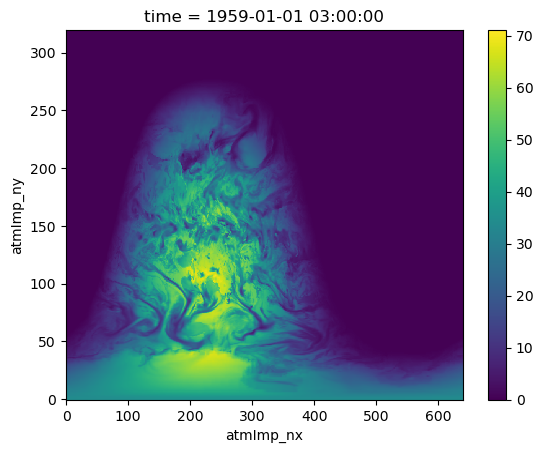

In [5]:
(atm_swdn.isel(time=0).atmImp_Faxa_swdn - atm_swnet.isel(time=0).atmImp_Faxa_swnet).plot()

In [7]:
PATH_out = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_JRA.TL319_t232.daily_SST_ERA5_Alper_config/cpl/hist/'
filename_out = 'a.e30.A_JRA.TL319_t232.daily_SST_ERA5_Alper_config.cpl.hi.1959-01-01-10800.nc'

ds_out = xr.open_dataset(PATH_out + filename_out)

lat_out = ds_out.atmImp_lat.isel(time=0, drop = True)

weights = np.cos(np.deg2rad(lat_out))
weights = weights / weights.sum() 


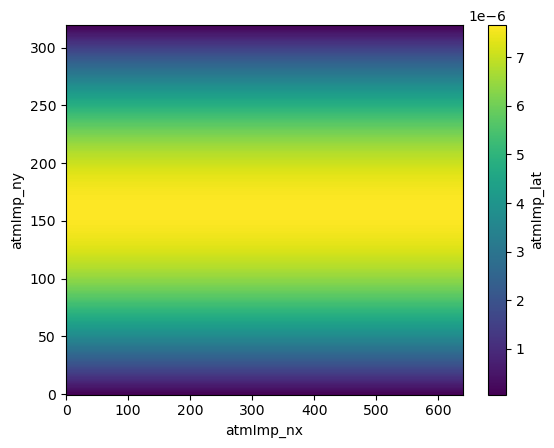

In [8]:
weights.plot()

In [9]:
atm_swdn.atmImp_Faxa_swdn.isel(time = 0, drop = True).weighted(weights).mean(dim=["atmImp_nx", "atmImp_ny"])

<xarray.DataArray 'atmImp_Faxa_swdn' ()> Size: 8B
array(182.61755274)

In [10]:
atm_swnet.atmImp_Faxa_swnet.isel(time = 0, drop = True).weighted(weights).mean(dim=["atmImp_nx", "atmImp_ny"])

<xarray.DataArray 'atmImp_Faxa_swnet' ()> Size: 8B
array(170.85634951)

# Calculate mean for every timestep

In [43]:
swdn_out_all = [] 
lwdn_out_all = [] 
swnet_out_all = [] 

for itime in range(0, len(atm_swnet.time)):

    if itime%200==0:
        print(itime)

    var_name = 'atmImp_Faxa_swnet'
    # out_w_mean = atm_swnet[var_name].isel(time = itime, drop = True).weighted(weights).mean(dim=["atmImp_nx", "atmImp_ny"]).values
    out_w_mean = atm_swnet[var_name].isel(time = itime, drop = True).sum(dim=["atmImp_nx", "atmImp_ny"]).values
    swnet_out_all.append(out_w_mean)
    
    var_name = 'atmImp_Faxa_swdn'
    # out_w_mean = atm_swdn[var_name].isel(time = itime, drop = True).weighted(weights).mean(dim=["atmImp_nx", "atmImp_ny"]).values
    out_w_mean = atm_swdn[var_name].isel(time = itime, drop = True).sum(dim=["atmImp_nx", "atmImp_ny"]).values
    swdn_out_all.append(out_w_mean)
    
    var_name = 'atmImp_Faxa_lwdn'
    # out_w_mean = atm_lwdn[var_name].isel(time = itime, drop = True).weighted(weights).mean(dim=["atmImp_nx", "atmImp_ny"]).values
    out_w_mean = atm_lwdn[var_name].isel(time = itime, drop = True).sum(dim=["atmImp_nx", "atmImp_ny"]).values

    lwdn_out_all.append(out_w_mean)

0
200


In [44]:
swnet_out_da = xr.DataArray(
    np.array(swnet_out_all),
    dims=['time'],
    coords={'time': pd.to_datetime([str(t) for t in atm_swnet.time.values])})

swdn_out_da = xr.DataArray(
    np.array(swdn_out_all),
    dims=['time'],
    coords={'time': pd.to_datetime([str(t) for t in atm_swnet.time.values])})

lwdn_out_da = xr.DataArray(
    np.array(lwdn_out_all),
    dims=['time'],
    coords={'time': pd.to_datetime([str(t) for t in atm_swnet.time.values])})

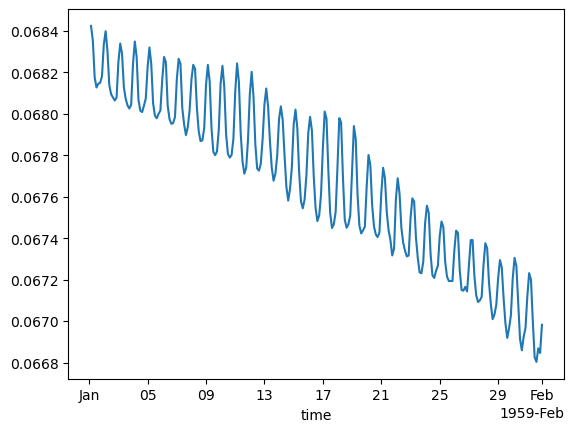

In [45]:
(1 - swnet_out_da/swdn_out_da).plot()

In [46]:
swnet_out_da.mean()

<xarray.DataArray ()> Size: 8B
array(33321968.90452361)

In [47]:
swdn_out_da.mean()

<xarray.DataArray ()> Size: 8B
array(35741140.65926187)

In [16]:
lwdn_out_da.mean()

<xarray.DataArray ()> Size: 8B
array(329.05043069)

# Plot the forcing timeseries and mean

In [37]:
PATH_forcing = '/glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.5_noleap/'
filename_forcing = 'JRA.v1.5.swdn.TL319.1959.210504.nc'

ds_forcing = xr.open_dataset(PATH_forcing + filename_forcing)

lat_forcing = ds_forcing.latitude
lon_forcing = ds_forcing.longitude

weights_1d = np.cos(np.deg2rad(lat_forcing))
weights_2d = np.outer(weights_1d, np.ones(len(lon_forcing)))
weights_2d = weights_2d / np.sum(weights_2d)


weights_da = xr.DataArray(
    weights_2d,
    dims=['latitude', 'longitude'],
    coords={'latitude': lat_forcing, 'longitude': lon_forcing})


In [39]:
swdn_forcing_all = [] 

for itime in range(0, len(ds_forcing.time)):

    if itime%200==0:
        print(itime)
    
    var_name = 'swdn'
    # out_w_mean = ds_forcing[var_name].isel(time = itime, drop = True).weighted(weights_da).mean(dim=["latitude", "longitude"])
    out_w_mean = ds_forcing[var_name].isel(time = itime, drop = True).sum(dim=["latitude", "longitude"])
    swdn_forcing_all.append(out_w_mean)

0
200
400
600
800
1000
1200
1400
1600
1800
2000
2200
2400
2600
2800


In [40]:
filename_forcing = 'JRA.v1.5.lwdn.TL319.1959.210504.nc'
ds_forcing = xr.open_dataset(PATH_forcing + filename_forcing)


lwdn_forcing_all = [] 

for itime in range(0, len(ds_forcing.time)):

    if itime%200==0:
        print(itime)
    
    var_name = 'lwdn'
    # out_w_mean = ds_forcing[var_name].isel(time = itime, drop = True).weighted(weights_da).mean(dim=["latitude", "longitude"])
    out_w_mean = ds_forcing[var_name].isel(time = itime, drop = True).sum(dim=["latitude", "longitude"])

    lwdn_forcing_all.append(out_w_mean)

0
200
400
600
800
1000
1200
1400
1600
1800
2000
2200
2400
2600
2800


In [41]:
swdn_forcing_da = xr.DataArray(
    swdn_forcing_all,
    dims=['time'],
    coords={'time': pd.to_datetime([str(t) for t in ds_forcing.time.values])})

lwdn_forcing_da = xr.DataArray(
    lwdn_forcing_all,
    dims=['time'],
    coords={'time': pd.to_datetime([str(t) for t in ds_forcing.time.values])})

In [48]:
swdn_forcing_da.isel(time = slice(0,248)).mean('time')

<xarray.DataArray ()> Size: 4B
array(36328688., dtype=float32)

In [49]:
swdn_out_da.mean('time')

<xarray.DataArray ()> Size: 8B
array(35741140.65926187)

In [50]:
lwdn_out_da.mean('time')

<xarray.DataArray ()> Size: 8B
array(59273189.68560311)

In [51]:
lwdn_forcing_da.isel(time = slice(0,248)).mean('time')

<xarray.DataArray ()> Size: 4B
array(59272752., dtype=float32)

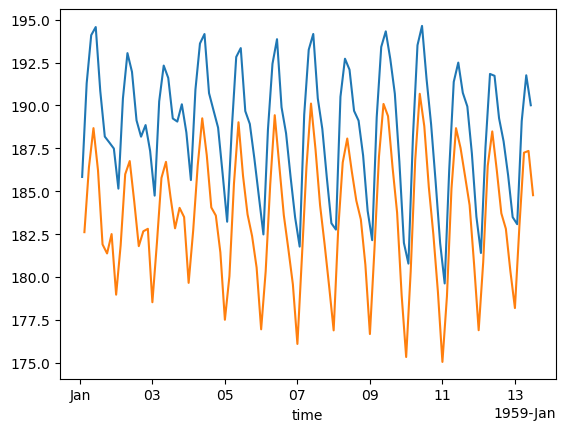

In [33]:
swdn_forcing_da.isel(time = slice(0,100)).plot()
swdn_out_da.isel(time = slice(0,100)).plot()

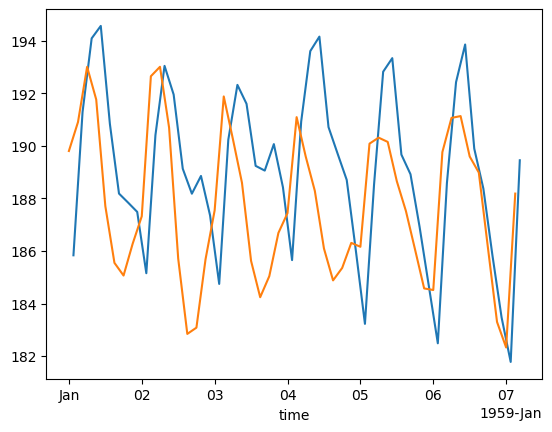

In [27]:
swdn_forcing_da.isel(time = slice(0,50)).plot()
swdn_out_da.resample(time='3h').mean().isel(time = slice(0,50)).plot()

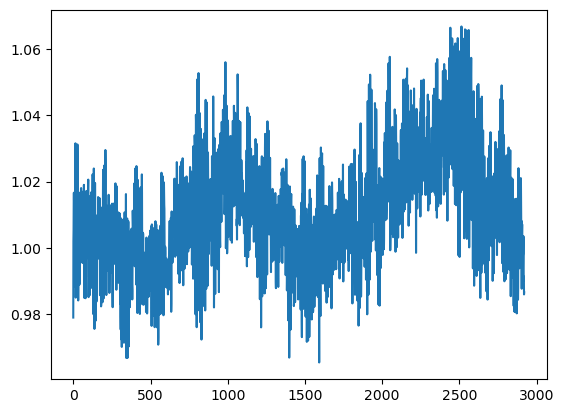

In [28]:
plt.plot(swdn_forcing_da.values/swdn_out_da.resample(time='3h').mean().values)

In [29]:
swdn_out_da.resample(time='3h').mean().mean()

<xarray.DataArray ()> Size: 8B
array(180.78412652)

In [30]:
lwdn_forcing_da.mean()

<xarray.DataArray ()> Size: 8B
array(338.59227676)

In [31]:
lwdn_out_da.mean()

<xarray.DataArray ()> Size: 8B
array(336.80063059)

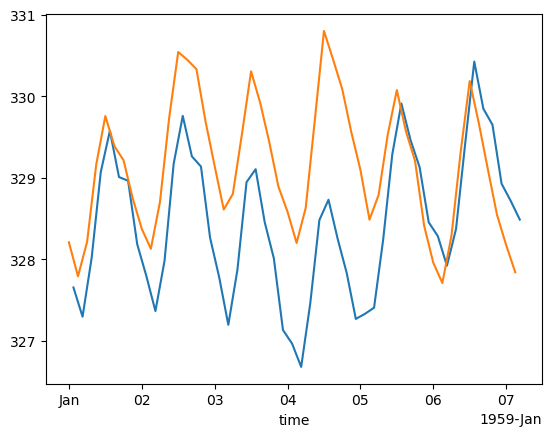

In [32]:
lwdn_forcing_da.isel(time = slice(0,50)).plot()
lwdn_out_da.resample(time='3h').mean().isel(time = slice(0,50)).plot()

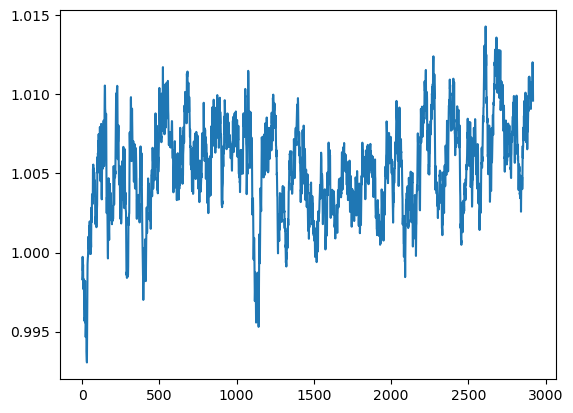

In [33]:
plt.plot(lwdn_forcing_da.values/lwdn_out_da.resample(time='3h').mean().values)

# AUX

# Compare first steps of forcing and outputs

1.0000000000000002

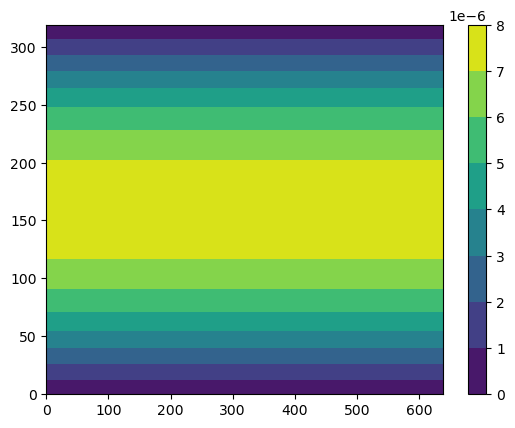

In [2]:
# PATH_forcing = '/glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.5_noleap/'
# filename_forcing = 'JRA.v1.5.swdn.TL319.1959.210504.nc'

# ds_forcing = xr.open_dataset(PATH_forcing + filename_forcing)

# lat_forcing = ds_forcing.latitude
# lon_forcing = ds_forcing.longitude

# weights_1d = np.cos(np.deg2rad(lat_forcing))
# weights_2d = np.outer(weights_1d, np.ones(len(lon_forcing)))
# weights_2d = weights_2d / np.sum(weights_2d)


# weights_da = xr.DataArray(
#     weights_2d,
#     dims=['latitude', 'longitude'],
#     coords={'latitude': lat_forcing, 'longitude': lon_forcing},
#     name='weights',
#     attrs={'description': 'Normalized 2D latitude weights', 'units': '1'}
# )

# plt.contourf(weights_da)
# plt.colorbar()

# np.sum(weights_2d)

In [6]:
# ds_forcing.swdn.isel(time = 0, drop = True).weighted(weights_da).mean(dim=["latitude", "longitude"])

<xarray.DataArray 'swdn' ()> Size: 8B
array(185.83655671)

<xarray.DataArray 'atmImp_lat' ()> Size: 8B
array(1.)

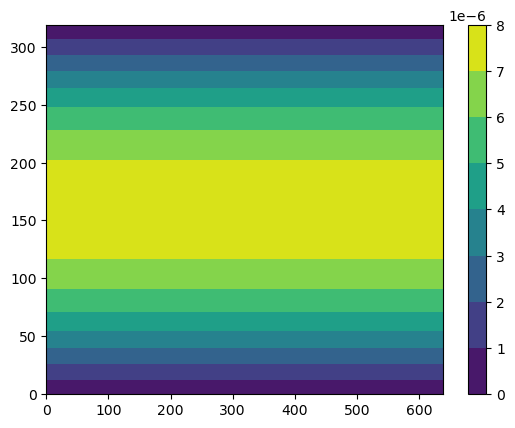

In [18]:
# PATH_out = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_JRA.TL319_t232.time_varying_HadOIBl_upd_swdn/cpl/hist/'
# filename_out = 'a.e30.A_JRA.TL319_t232.time_varying_HadOIBl_upd_swdn.cpl.hi.1959-01-01-05400.nc'

# ds_out = xr.open_dataset(PATH_out + filename_out)

# lat_out = ds_out.atmImp_lat.isel(time=0, drop = True)

# weights = np.cos(np.deg2rad(lat_out))
# weights = weights / weights.sum() 

# weights_da = xr.DataArray(
#     weights_2d,
#     dims=['atmImp_ny', 'atmImp_nx'],
#     coords={'atmImp_ny': ds_out.atmImp_ny.values, 'atmImp_nx': ds_out.atmImp_nx.values},
#     name='weights',
#     attrs={'description': 'Normalized 2D latitude weights', 'units': '1'}
# )


# plt.contourf(weights)
# plt.colorbar()

# np.sum(weights)

In [21]:
# ds_out.atmImp_Faxa_swdn.isel(time = 0, drop = True).weighted(weights).mean(dim=["atmImp_nx", "atmImp_ny"])

<xarray.DataArray 'atmImp_Faxa_swdn' ()> Size: 8B
array(187.61612152)

# Compare raw output and output after cdo postprocessing

In [6]:
# PATH_out = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_JRA.TL319_t232.time_varying_HadOIBl_upd_swdn/cpl/hist/'
# filename_out = 'a.e30.A_JRA.TL319_t232.time_varying_HadOIBl_upd_swdn.cpl.hi.1959-01-01-21600.nc'

# ds_out = xr.open_dataset(PATH_out + filename_out)

# lat_out = ds_out.atmImp_lat.isel(time = 0, drop = True)

# weights = np.cos(np.deg2rad(lat_out))
# weights = weights / weights.sum() 
# plt.contourf(weights)
# plt.colorbar()

# weights.sum()

# var_name = 'atmImp_Faxa_swnet'
# out_w_mean = ds_out[var_name].weighted(weights).mean(dim=["atmImp_nx", "atmImp_ny"])
# print(out_w_mean)

# var_name = 'atmImp_Faxa_swdn'
# out_w_mean = ds_out[var_name].weighted(weights).mean(dim=["atmImp_nx", "atmImp_ny"])
# print(out_w_mean)

# var_name = 'atmImp_Faxa_lwdn'
# out_w_mean = ds_out[var_name].weighted(weights).mean(dim=["atmImp_nx", "atmImp_ny"])
# print(out_w_mean)

In [7]:
# PATH = '/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA.TL319_t232.time_varying_HadOIBl_upd_swdn/1959/'
# filename_swdn = 'a.e30.A_JRA.TL319_t232.time_varying_HadOIBl_upd_swdn.1959.atm_swdn.nc'
# filename_lwdn = 'a.e30.A_JRA.TL319_t232.time_varying_HadOIBl_upd_swdn.1959.atm_lwdn.nc'
# filename_swnet = 'a.e30.A_JRA.TL319_t232.time_varying_HadOIBl_upd_swdn.1959.atm_swnet.nc'


# weights = np.cos(np.deg2rad(lat_out))
# weights = weights / weights.sum() 
# plt.contourf(weights)
# plt.colorbar()

# weights.sum()

# swdn_all = [] 
# lwdn_all = [] 
# swnet_all = [] 

# for itime in range(0, 1459):

#     if itime%10==0:
#         print(itime)

#     var_name = 'atmImp_Faxa_swnet'
#     out_w_mean = xr.open_dataset(PATH + filename_swnet)[var_name].isel(time = itime, drop = True).weighted(weights).mean(dim=["atmImp_nx", "atmImp_ny"])
#     # print(out_w_mean)
#     swnet_all.append(out_w_mean)
    
#     var_name = 'atmImp_Faxa_swdn'
#     out_w_mean = xr.open_dataset(PATH + filename_swdn)[var_name].isel(time = itime, drop = True).weighted(weights).mean(dim=["atmImp_nx", "atmImp_ny"])
#     # print(out_w_mean)
#     swdn_all.append(out_w_mean)
    
#     var_name = 'atmImp_Faxa_lwdn'
#     out_w_mean = xr.open_dataset(PATH + filename_lwdn)[var_name].isel(time = itime, drop = True).weighted(weights).mean(dim=["atmImp_nx", "atmImp_ny"])
#     # print(out_w_mean)
#     lwdn_all.append(out_w_mean)

In [8]:
# np.mean(lwdn_all)

In [9]:
# np.mean(swdn_all)

In [10]:
# np.mean(swnet_all)

In [8]:
PATH_raw = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_JRA.TL319_t232.time_varying_HadOIBl/cpl/hist/'
filename_raw = 'a.e30.A_JRA.TL319_t232.time_varying_HadOIBl.cpl.hi.1959-12-31-05400.nc'
mask_atm = xr.open_dataset("/glade/u/home/mmarkina/Code/atmImp_mask.nc", engine="netcdf4")['mask']

lon_atm = mask_atm.lon
lat_atm = mask_atm.lat

# lat_atm =  xr.open_dataset(PATH_raw + filename_raw).atmImp_lat.isel(time = 0, drop = True)

<xarray.DataArray ()> Size: 8B
array(1.)

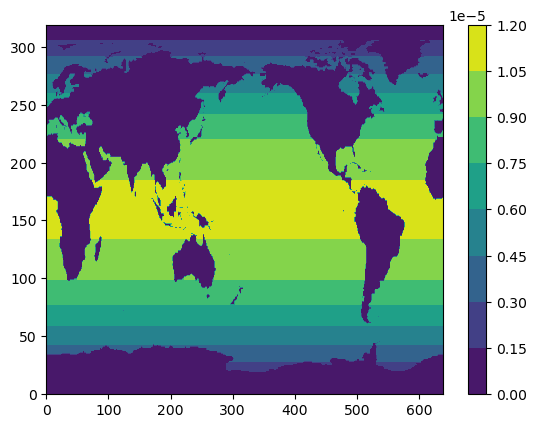

In [18]:
weights = np.cos(np.deg2rad(lat_atm))*mask_atm
weights = weights / weights.sum()  # Normalize so they sum to 1
plt.contourf(weights)
plt.colorbar()

weights.sum()

In [19]:
weights = weights.rename({"y": "atmImp_ny", "x": "atmImp_nx"})

# atmImp_nx = 640
# atmImp_ny = 320

# weights_da = xr.DataArray(
#     weights,
#     dims=("atmImp_ny", "atmImp_nx"),
#     coords={"atmImp_ny": np.arange(atmImp_ny), "atmImp_nx": np.arange(atmImp_nx)},
#     name="weights"
# )

In [24]:
PATH = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA.TL319_t232.time_varying_HadOIBl_upd_swdn/1960/" 
# PATH = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55raw.TL319_t232.time_varying_HadOIBl/MONTHLY/" 
filename = "1960.atm_lwdn.monthly.nc"
var_name = "atmImp_Faxa_lwdn"

yearly_means = {}

ds = xr.open_dataset(PATH + filename, engine="netcdf4")

weights_br = weights.broadcast_like(ds[var_name])  # Ensure shape matches the data variable
nan_counts = weights_br.isnull().sum()
print(nan_counts)

var_time_series = ds[var_name].weighted(weights_br).mean(dim=["atmImp_nx", "atmImp_ny"])
var_time_series["time"] = pd.to_datetime([t.strftime('%Y-%m-%d') for t in var_time_series["time"].values])
# yearly_mean = var_time_series.resample(time="1YE").mean()
# yearly_means[key] = yearly_mean

del weights_br

<xarray.DataArray ()> Size: 8B
array(0)


In [25]:
var_time_series.mean('time')

<xarray.DataArray 'atmImp_Faxa_lwdn' ()> Size: 8B
array(352.07040011)

# Plotting ocen swnet

In [ ]:
# yearly_mean.plot()
# plt.title('JRA-do (atm SWNET)')

In [2]:
PATH1_raw = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_JRA55raw.TL319_t232.time_varying_HadOIBl/cpl/hist/'

filename1_raw = 'a.e30.A_JRA55raw.TL319_t232.time_varying_HadOIBl.cpl.hi.1959-12-31-64800.nc'

lat1_raw = xr.open_dataset(PATH1_raw + filename1_raw, engine="netcdf4")['ocnExp_lat'].isel(time=0, drop = True).rename({"ocnExp_ny": "y", "ocnExp_nx": "x"})

mask1 = xr.open_dataset(PATH1_raw + filename1_raw, engine="netcdf4")['ocnImp_So_omask'].isel(time=0, drop = True).rename({"ocnImp_ny": "y", "ocnImp_nx": "x"})

<xarray.DataArray ()> Size: 8B
array(1.)

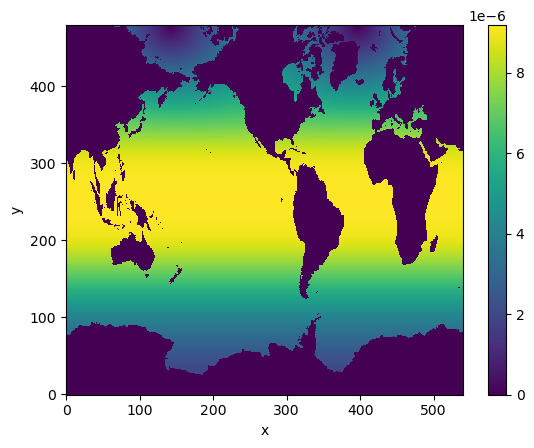

In [3]:
weights_1 = np.cos(np.deg2rad(lat1_raw))*mask1
weights_1 = weights_1 / weights_1.sum()  # Normalize so they sum to 1
weights_1.plot()
weights_1.sum()

In [4]:
weights_1 = weights_1.rename({"y": "ocnExp_ny", "x": "ocnExp_nx"})

In [11]:
PATH = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA.TL319_t232.time_varying_HadOIBl_upd_swdn/1959/" 
# PATH = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55raw.TL319_t232.time_varying_HadOIBl/MONTHLY/" 
filename = "1959.swnet.monthly.nc"
var_name = "ocnExp_Foxx_swnet"

yearly_means = {}

ds = xr.open_dataset(PATH + filename, engine="netcdf4")

weights_br = weights_1.broadcast_like(ds[var_name])  # Ensure shape matches the data variable
nan_counts = weights_br.isnull().sum()
print(nan_counts)

var_time_series = ds[var_name].weighted(weights_br).mean(dim=["ocnExp_nx", "ocnExp_ny"])
var_time_series["time"] = pd.to_datetime([t.strftime('%Y-%m-%d') for t in var_time_series["time"].values])
# yearly_mean = var_time_series.resample(time="1YE").mean()
# yearly_means[key] = yearly_mean

del weights_br

<xarray.DataArray ()> Size: 8B
array(0)


In [12]:
var_time_series.mean('time')

<xarray.DataArray 'ocnExp_Foxx_swnet' ()> Size: 8B
array(170.10455999)

In [10]:
ls /glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55.TL319_t232.time_varying_HadOIBl_upd_swdn/

ls: cannot access '/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_JRA55.TL319_t232.time_varying_HadOIBl_upd_swdn/': No such file or directory
